# Assignment 3: Linear Models

Zoe Tankersley nab9pr

In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is considered linear if it is linear in its parameters. This means that the coefficients are *added* together to model the relationship between the dependent variable and independent variable(s). The relationship is represented graphically as a straight line, meaning there is a constant rate of change.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

The coefficient for a dummy variable represents the difference in the average value of y between that category and the baseline category that was dropped. The intercept is the mean of the baseline group, and each dummy coefficient shows how much higher or lower that category is relative to the baseline.

3. Can linear regression be used for classification? Explain why, or why not.

While linear regression can technically be used for classification, it is inferior to other methods like logistic regression. Since linear regression predicts continuous numerical values, it can output values that don't fall in the 0-1 probability range. Logistic regression constrains predictions to valid probabilities, making it ideal for classification.

4. What are signs that your linear model is over-fitting?

A model is overfitting if it fits the training data very closely but performs poorly on the test data. Signs of overfitting include a large gap between training and test error, overly complex fits on a graph, and high variability.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity occurs when two predictor variables are highly correlated and cancel each other out, making the model unstable. In two-stage least squares, the problematic variable is regressed on other variables to isolate its variation. Then, the predicted values from this first stage are used in the main regression to reduce the impact of collinearity.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

Nonlinear relationships can be modeled by transforming features, such as adding polynomial terms or interactions. The model then becomes nonlinear in x while remaining linear in its parameters.

7. What is the interpretation of the slope coefficient in a linear regression?

In linear regression, the slope coefficient represents the expected change in y for a one-unit increase in x, holding all other variables constant.

8. Compare the train/test split and $k$-fold cross validation.

Train/test split divides the data once, providing a single estimate of model performance. K-fold cross-validation, however, averages scores over k-iterations, making it more accurate for smaller datasets.

9. How is the $k$ in $k$-fold cross validation typically selected?

Choosing k in k-fold cross-validation involves balancing the bias-variance tradeoff. The most common choices are k=5 or k=10. A larger k reduces bias but is more computationally expensive, whereas a smaller k reduces variance but may be less accurate.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.


In [248]:
df=pd.read_csv("/content/undergrad_ml_assignments/data/Q1_clean.csv")
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [249]:
df.columns

Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='object')

In [250]:
df = df.rename(columns={'Neighbourhood ': 'Neighbourhood'})

In [251]:
grouped=df.groupby("Neighbourhood")[["Price","Review Scores Rating"]].mean()
print(grouped)


                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750


In [252]:
print("Most expensive borough:", grouped["Price"].idxmax())

Most expensive borough: Manhattan


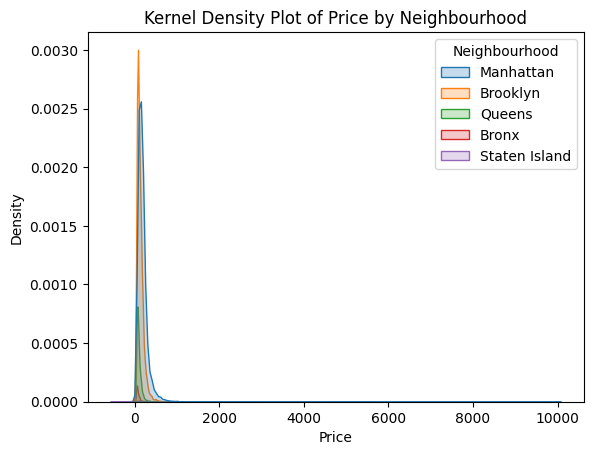

In [253]:
sns.kdeplot(data=df, x="Price", hue="Neighbourhood", fill=True)
plt.xlabel("Price")
plt.ylabel("Density")
plt.title("Kernel Density Plot of Price by Neighbourhood")
plt.show()

In [254]:
df["log_price"] = np.log(df["Price"])

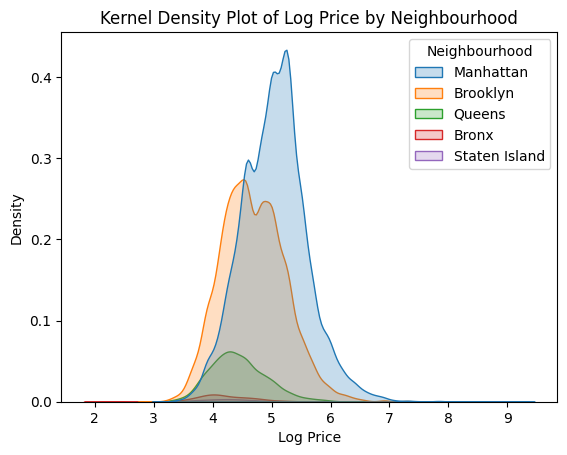

In [255]:
sns.kdeplot(data=df, x="log_price", hue="Neighbourhood", fill=True)
plt.xlabel("Log Price")
plt.ylabel("Density")
plt.title("Kernel Density Plot of Log Price by Neighbourhood")
plt.show()

2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?

In [256]:
dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True)

In [257]:
X = pd.concat([dummies], axis=1)
y = df['Price']

In [258]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model=model.fit(X,y)

In [259]:
print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: 75.27649769585331


,variable,coefficient
0,Brooklyn,52.470881
1,Manhattan,108.387789
2,Queens,21.580735
3,Staten Island,70.890169


For our dummy variables, we dropped the first category and the Bronx became our baseline neighborhood. This means that the intercept (75.28) is the average price in the Bronx and each coefficient is the difference between that neighborhood and the Bronx. Adding each coefficient to the intercept recovers the group means from part 1. Therefore, the regression results are connected to the table in part 1 because they express the means relative to a baseline.


3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.

In [260]:
X = df[['Review Scores Rating']]
y = df['Price']
model=LinearRegression()
model=model.fit(X,y)
print(f'Model intercept: {model.intercept_}')
print(f'Model coefficient: {model.coef_}')

Model intercept: 60.878390657123546
Model coefficient: [1.0208266]


For each one point increase in review scores rating, the expected price increases by $1.02 per night on average.

4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?

In [261]:
X = pd.concat([dummies, df[['Review Scores Rating']]], axis=1)
y = df['Price']
model=LinearRegression()
model=model.fit(X,y)
print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: -23.812561011672244


,variable,coefficient
0,Brooklyn,51.704240
1,Manhattan,108.228737
2,Queens,21.694600
3,Staten Island,71.766552
4,Review Scores Rating,1.081116


When regressing on both neighborhood and review scores, the slope on rating increases slightly from 1.02 to 1.08. This means that the positive effect of rating on price is consistent across neighborhoods. The neighborhood coefficients change very little, showing that the variation in price is mainly explained by location rather than rating.

5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?

In [262]:
X = df[['Review Scores Rating']].copy()
for col in dummies.columns:
    X[col + '_rating'] = dummies[col] * df['Review Scores Rating']

y = df['Price']

model = LinearRegression()
model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: 55.11825364116335


,variable,coefficient
0,Review Scores Rating,0.222718
1,Brooklyn_rating,0.568229
2,Manhattan_rating,1.176658
3,Queens_rating,0.233733
4,Staten Island_rating,0.459726


By allowing each neighborhood to have its own slope for Review Scores Rating, we see that the effect of rating on price differs by neighborhood. The Review Scores Rating variable in the regression represents the slope for the baseline neighborhood, Bronx, because there is no separate dummy for it. We can see that Manhattan has the strongest effect of rating on price, while the Bronx has the weakest, and Brooklyn, Queens, and Staten Island fall in between.




6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [263]:
X_neigh = pd.get_dummies(df['Neighbourhood'], drop_first=True)
X_rating = df[['Review Scores Rating']]
X_both = pd.concat([X_neigh, X_rating], axis=1)
X_interaction = df[['Review Scores Rating']].copy()
for col in dummies.columns:
    X_interaction[col + '_rating'] = dummies[col] * df['Review Scores Rating']

In [264]:
from sklearn.model_selection import KFold, cross_val_score
kfold = KFold(n_splits=10, shuffle=True, random_state=100)
def cv_mse(model, X, y):
    scores = cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')
    return -scores
model_neigh = LinearRegression()

mse_neigh = cv_mse(model, X_neigh, y)
mse_rating = cv_mse(model, X_rating, y)
mse_both = cv_mse(model, X_both, y)
mse_interaction = cv_mse(model, X_interaction, y)

print("Neighborhood only MSE:", np.mean(mse_neigh))
print("Rating only MSE:", np.mean(mse_rating))
print("Neighborhood + Rating MSE:", np.mean(mse_both))
print("Interaction model MSE:", np.mean(mse_interaction))

Neighborhood only MSE: 21159.02908891004
Rating only MSE: 22079.512358769138
Neighborhood + Rating MSE: 21074.09738730938
Interaction model MSE: 21049.357471633008


Cross-validation shows that location is the main driver of price because the Neighborhood-only model has a much lower MSE than the Rating-only model. Adding Review Scores Rating and the interactive model slightly improves predictive performance. This confirms that neighborhood differences dominate pricing, while review scores provide a small, location-dependent adjustment. The interaction model is the most accurate.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?

In [265]:
df=pd.read_csv('/content/undergrad_ml_assignments/data/cars_hw.csv')
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [266]:
grouped=df.groupby("Body_Type")["Price"].describe()
print(grouped)

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


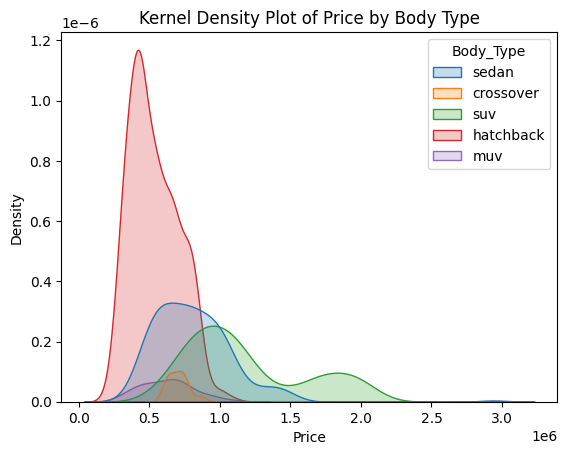

In [267]:
sns.kdeplot(data=df, x="Price", hue="Body_Type", fill=True)
plt.xlabel("Price")
plt.ylabel("Density")
plt.title("Kernel Density Plot of Price by Body Type")
plt.show()

In [268]:
print("Most expensive car type:", grouped["mean"].idxmax())
print("Most variable car type:", grouped["std"].idxmax())

Most expensive car type: suv
Most variable car type: suv



  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?

In [269]:
X=df[["Seating_Capacity"]]
y=df["Price"]
model=LinearRegression()
model=model.fit(X,y)
print(f'Model intercept: {model.intercept_}')
print(f'Model coefficient: {model.coef_}')

Model intercept: 439032.0141018266
Model coefficient: [59267.99803672]


The slope coefficient is 59,268. This means that adding one more seat increases the price by 59,268 Indian rupees.

In [270]:
dummies = pd.get_dummies(df["Seating_Capacity"], drop_first=True)
X = pd.concat([dummies], axis=1)
y = df['Price']
model=LinearRegression()
model=model.fit(X,y)
print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':X.columns, 'coefficient':model.coef_ })

Model intercept: 188000.00000000314


,variable,coefficient
0,5,5.464839e+05
1,6,1.456000e+06
2,7,7.359487e+05
3,8,2.718000e+05


When we treat Seating_Capacity as a one hot encoded variable, the differences in price are not linear. Sometimes adding a seat increases the price a lot, such as the jump from 5 to 6 seats. Other times it decreases the price, such as the jump from 6 to 7 seats. These price changes are irregular and nonlinear.

  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.

In [271]:
Age=2026-df["Make_Year"]
df["Age"]=Age
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,9
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,10
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,7
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,9
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,9


In [272]:
y=df['Price']
kfold = KFold(n_splits=10, shuffle=True, random_state=100)
def cv_mse(X, y):
    scores=cross_val_score(LinearRegression(), X, y, cv=kfold, scoring='neg_mean_squared_error')
    return -np.mean(scores)
results={}
for d in range(1,15):
    X=pd.DataFrame()
    for power in range(1,d+1):
        X["Age^"+str(power)]=df["Age"]**power
    mse=cv_mse(X,y)
    results[d]=mse
for degree, mse in results.items():
    print(f"Degree {degree}: MSE = {mse}")


Degree 1: MSE = 97593991873.84819
Degree 2: MSE = 97788769710.30014
Degree 3: MSE = 97182824586.85364
Degree 4: MSE = 96657152963.87352
Degree 5: MSE = 95734209145.1779
Degree 6: MSE = 95928603339.2005
Degree 7: MSE = 95394591823.72777
Degree 8: MSE = 95673788591.43973
Degree 9: MSE = 95632519298.55978
Degree 10: MSE = 95354958984.82657
Degree 11: MSE = 95146668073.43669
Degree 12: MSE = 95292198631.81369
Degree 13: MSE = 95798290063.62923
Degree 14: MSE = 96410294704.05064


In [273]:
best_degree = min(results, key=results.get)
print("Optimal number of powers:", best_degree)

Optimal number of powers: 11


Based on the 10-fold cross-validation, the model with the lowest mean squared error used degree 11. This means that including up to Age^11 provides the best balance between bias and variance.



  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


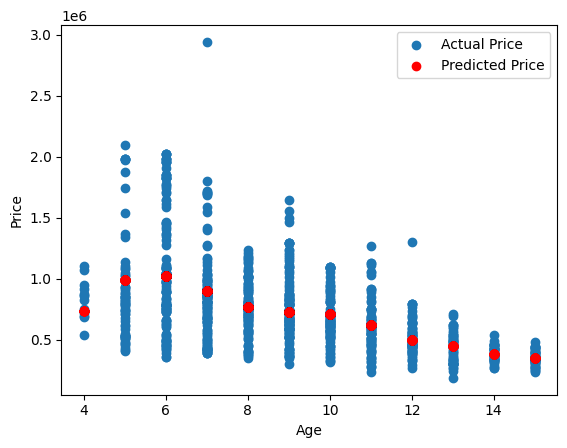

In [274]:
X = pd.DataFrame({
    'Age': df['Age'],
    'Age^2': df['Age']**2,
    'Age^3': df['Age']**3,
    'Age^4': df['Age']**4,
    'Age^5': df['Age']**5,
    'Age^6': df['Age']**6,
    'Age^7': df['Age']**7,
    'Age^8': df['Age']**8,
    'Age^9': df['Age']**9,
    'Age^10': df['Age']**10,
    'Age^11': df['Age']**11}
              )
y = df['Price']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
plt.scatter(df['Age'], df['Price'], label='Actual Price')
plt.scatter(df['Age'], y_pred, label='Predicted Price', color='red')
plt.xlabel('Age')
plt.ylabel('Price')
plt.legend()
plt.show()

The predicted prices generally follow the pattern of the actual data, indicating that the model captures the relationship between age and price reasonably well.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.



In [275]:
df=pd.read_csv('/content/undergrad_ml_assignments/data/heart_hw.csv')
df.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?

In [276]:
a=df[df["transplant"]=="control"]["y"].mean()
print('a:',a)
b=df[df["transplant"]=="treatment"]["y"].mean()
print('b:',b)
ate=b-a
print('b-a:',ate)

a: 0.11764705882352941
b: 0.34782608695652173
b-a: 0.23017902813299232


The average treatment effect (ATE) on three-year survival for heart transplant interventions is 0.23.

2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.

In [277]:
X = pd.get_dummies(df['transplant'], drop_first=True)
y = df['y']
model=LinearRegression()
model=model.fit(X,y)
print(f'Model intercept: {model.intercept_}')
print(f'Model coefficient: {model.coef_}')

Model intercept: 0.1176470588235293
Model coefficient: [0.23017903]


The intercept of the linear model is nearly identical to 'a', which is the proportion of people who survived in the control group. The coefficient for the transplant variable is virtually identical to the treatment average effect ('b-a'). This shows that in a linear model with a single dummy variable, the intercept represents the mean of the control group, and the coefficient of the dummy variable represents the difference in means between the treatment and control group, which is the ATE.


3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?

In [278]:
X = pd.get_dummies(df['transplant'], drop_first=True)
X['age'] = df['age']
y = df['y']
model=LinearRegression()
model.fit(X,y)
print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':X.columns, 'coefficient':model.coef_ })

Model intercept: 0.7019569721740947


,variable,coefficient
0,treatment,0.264702
1,age,-0.013607


When we control for age, the coefficient for transplant increases from 0.2302 to 0.2647. This means that after accounting for a patient's age, the estimated positive effect of a heart transplant on survival is slightly larger than when age is not considered.

The intercept (0.7019) represents the predicted probability of a control group patient who is 0 years old. Since 0 is outside the range of data, the intercept doesn't have a meaningful interpretation and is rather just a baseline for calculations.

The coefficient for treatment (0.2647) represents how much more likely a patient is to survive when they receive a transplant compared to a patient of the *same age* that did not receive a transplant.

The coefficient for age (-0.0136) represents the change in predicted probability of survival for each one year increase in age, holding the transplant status constant. For every year older a patient is, their chance of survival decreases by approximately 1.36%.



4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?

In [279]:
X = pd.get_dummies(df['transplant'], drop_first=True)
X['age'] = df['age']
X['interaction'] = X['treatment'] * df['age']
y = df['y']
model=LinearRegression()
model.fit(X,y)
print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':X.columns, 'coefficient':model.coef_ })

Model intercept: 0.35486517529945855


,variable,coefficient
0,treatment,0.907751
1,age,-0.005524
2,interaction,-0.014591


When we include the interaction between transplant and age, I first noticed the drastic changes in the treatment and age coefficients. These represent the effect of the variable when the other interacting variable is zero, acting as baselines. The interaction coefficient, however, tells us how the effect of treatment changes for each one-unit increase in age, or conversely how the effect of age changes when treatment is applied. This indicates that the effect of the transplant decreases as age increases. In other words, transplants are more effective for younger patients than older ones.

5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.

In [280]:
X_treat=pd.get_dummies(df['transplant'], drop_first=True)
X_both=pd.concat([X_treat, df['age']], axis=1)
X_interaction_term = X_treat['treatment'] * df['age']
X_interaction_term.name = 'interaction'
X_interaction = pd.concat([X_treat, df['age'], X_interaction_term], axis=1)

In [281]:
kfold = KFold(n_splits=10, shuffle=True, random_state=100)
def cv_mse(X, y):
    scores=cross_val_score(LinearRegression(), X, y, cv=kfold, scoring='neg_mean_squared_error')
    return -scores

mse_treat = cv_mse(X_treat, y)
mse_both = cv_mse(X_both, y)
mse_interaction = cv_mse(X_interaction, y)

print("Treatment only MSE:", np.mean(mse_treat))
print("Treatment + Age MSE:", np.mean(mse_both))
print("Treatment + Age Interaction MSE:", np.mean(mse_interaction))


Treatment only MSE: 0.19366383979017968
Treatment + Age MSE: 0.18171967184387974
Treatment + Age Interaction MSE: 0.18067090272965358


Incorporating the interaction between age and treatment leads to more accurate predictions of three-year survival.





6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


Using a predictive model for transplant access raises several ethical and practical concerns. For one, it is essential that the model is constructed with unbiased, quality data. If the training data underrepresents certain demographic groups or reflects systemic disparities in healthcare access, the model could perpetuate these biases. The complex nature of the model could also inhibit transparency, which is crucial when life-or-death decisions are being made. When the model is deployed, it is imperative that there is equity in access, sufficient human oversight, and accountability for model errors. Finally, it is important that the model is updated to reflect advances in medical sciences. These ethical concerns must be taken into consideration when implementing machine learning into a sensitive area such as healthcare.